In [25]:
import pandas as pd
import numpy as np
import duckdb as db

# Import data + convert to parquet

In [26]:
con = db.connect()

con.execute("""
    COPY (
        SELECT *
        FROM read_json_auto(
            'iowa_liquor_sales_2026_1263_rows/**/*.json'
        )
    )
    TO 'liquor.parquet' (FORMAT PARQUET)
""")

df = pd.read_parquet("liquor.parquet")

df.head()

,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,item_no,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158,19127,MARSHALL,1022200,...,88296,PATRON SILVER,12,750,24.99,37.49,60,2249.40,45.0,11.887740
1,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158,19127,MARSHALL,1082200,...,69947,RUMPLE MINZE PEPPERMINT SCHNAPPS LIQUEUR,12,1000,16.99,25.49,36,917.64,36.0,9.510192
2,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1022200,...,87484,DON JULIO BLANCO,12,375,14.00,22.00,3,67.00,1.0,0.000000
3,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1022200,...,88296,PATRON SILVER,12,750,24.00,37.00,12,449.00,9.0,2.000000
4,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1081300,...,84393,99 WATERMELON PET MINI,1,50,54.00,81.00,1,81.00,0.0,0.000000


# Info + EDA

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952161 entries, 0 to 1952160
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   invoice_id           object 
 1   ordered_on           object 
 2   store_no             object 
 3   store_name           object 
 4   store_address        object 
 5   store_city           object 
 6   store_zip_code       object 
 7   county_fips_code     object 
 8   county_name          object 
 9   category_code        object 
 10  category_name        object 
 11  vendor_number        object 
 12  vendor_name          object 
 13  item_no              object 
 14  im_desc              object 
 15  pack                 object 
 16  bottle_volume_ml     int64  
 17  state_bottle_cost    float64
 18  state_bottle_retail  float64
 19  sales_bottles        object 
 20  sales_dollars        float64
 21  sales_liters         float64
 22  sales_gallons        float64
dtypes: float64(5), int64(1), object(

In [28]:
df.describe()

,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_dollars,sales_liters,sales_gallons
count,1.952161e+06,1.952161e+06,1.952161e+06,1.952161e+06,1.952161e+06,1.952161e+06
mean,7.510093e+02,1.399817e+01,2.101696e+01,1.647814e+02,8.617866e+00,2.248266e+00
std,5.433100e+02,2.436581e+01,3.654744e+01,6.069239e+02,4.026066e+01,1.063415e+01
min,2.000000e+01,0.000000e+00,1.000000e+00,-3.240000e+03,-1.200000e+02,-3.170064e+01
25%,3.750000e+02,6.000000e+00,9.000000e+00,4.950000e+01,1.000000e+00,1.981290e-01
50%,7.500000e+02,1.000000e+01,1.500000e+01,8.666000e+01,4.500000e+00,1.188774e+00
75%,1.000000e+03,1.650000e+01,2.475000e+01,1.664400e+02,9.000000e+00,2.377548e+00
max,4.500000e+03,3.750000e+03,5.625000e+03,2.608320e+05,1.320000e+04,3.487000e+03


In [29]:
df.isna().sum()

invoice_id                0
ordered_on                0
store_no                  0
store_name                0
store_address             0
store_city                0
store_zip_code            0
county_fips_code       4129
county_name               0
category_code             0
category_name             0
vendor_number             0
vendor_name               0
item_no                   0
im_desc                   0
pack                      0
bottle_volume_ml          0
state_bottle_cost         0
state_bottle_retail       0
sales_bottles             0
sales_dollars             0
sales_liters              0
sales_gallons             0
dtype: int64

- aggregate by store zip code and find bottles sold

        -> where are people ordering? what stores ordering?

- aggregate by ordered on

        -> look at ordered on and what type of alcohol ordered on dates

        -> what seasons have the most orders? what are they ordering? where are they?

- aggregate by category_code?

        -> most commonly bought liquor purchases? who is ordering them? when are they ordering? how much are they buying them for? how much do they order?

In [30]:
df['store_zip_code'].value_counts()
df['store_name'].value_counts()
df['county_name'].value_counts()

county_name
POLK          374636
LINN          165505
SCOTT         119424
BLACK HAWK     98487
JOHNSON        92563
               ...  
ADAMS           1642
DECATUR         1569
RINGGOLD        1125
TAYLOR          1077
DAVIS            850
Name: count, Length: 100, dtype: int64

<Axes: >

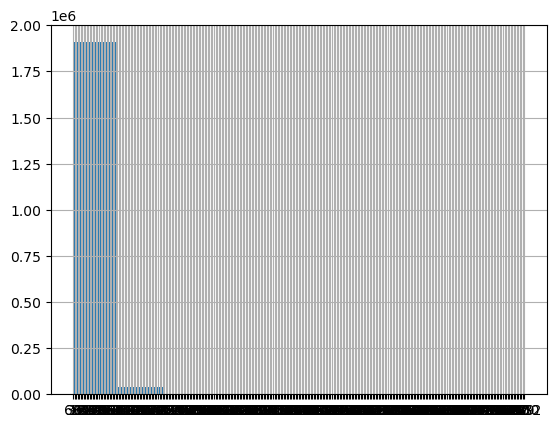

In [ ]:
df[["sales_bottles", "sales_dollars", "sales_liters"]].describe()


# Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

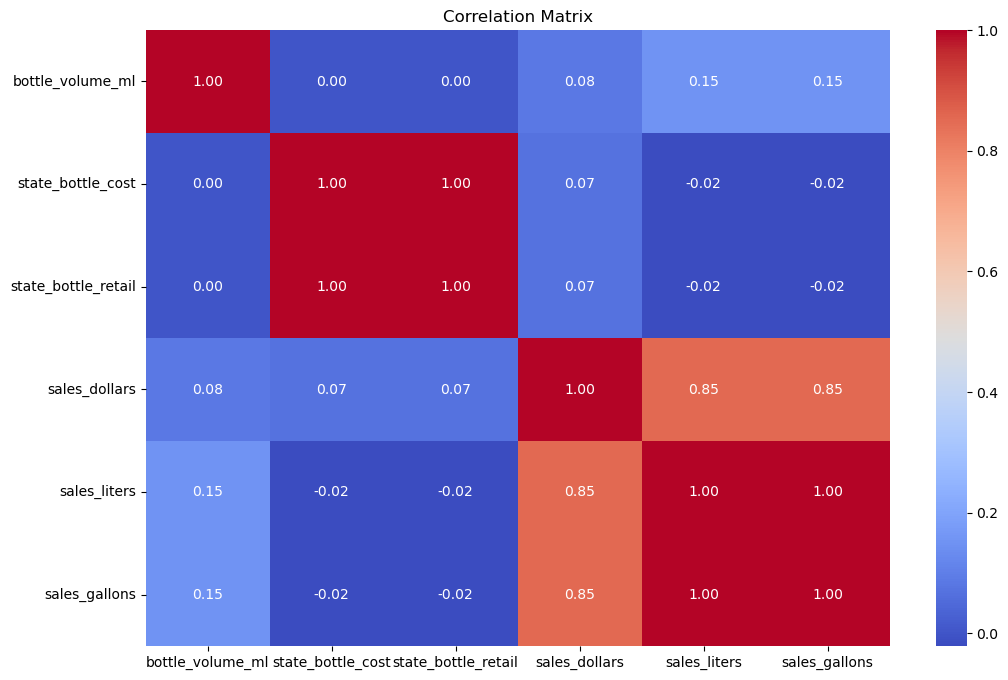

In [ ]:
corr = df.corr(numeric_only = True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['sale_dollars'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Sale Dollars')

KeyError: 'sale_dollars'

<Figure size 1000x600 with 0 Axes>